## 1. Setup and Load Data

### 1.1 Install Dependences and Setup

In [1]:
import os
import tensorflow as tf

2025-06-07 19:13:23.981690: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-07 19:13:28.947646: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-07 19:13:38.018561: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-06-07 19:13:38.018561: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Avoid OOM by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

2025-06-07 19:13:58.735747: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


### 1.2 Remove Doddy Images

In [3]:
import cv2
import imghdr
import matplotlib.pyplot as plt

In [4]:
data_dir = 'data'

In [5]:
os.listdir(os.path.join(data_dir, 'happy'))

['images - 2025-06-07T123719.508.jpeg',
 '5fe07bbb5b1cedf547980dcdc0862e79.jpg',
 'images - 2025-06-07T123722.769.jpeg',
 '360_F_553721043_dud5E2xUoiQaOEfJ4fLGgp7ZuQ7lsWKM.jpg',
 'images - 2025-06-07T123722.149.jpeg',
 '6186015_stock-photo-happy-people-crowd.jpg',
 'happy-person.jpg',
 'images - 2025-06-07T123718.984.jpeg',
 'images - 2025-06-07T123721.609.jpeg',
 'images - 2025-06-07T123726.352.jpeg',
 'images - 2025-06-07T123725.986.jpeg',
 'images - 2025-06-07T123721.024.jpeg',
 'images - 2025-06-07T123725.567.jpeg',
 'images - 2025-06-07T123726.364.jpeg',
 'images - 2025-06-07T123725.855.jpeg',
 'images - 2025-06-07T123724.523.jpeg',
 'images - 2025-06-07T123724.481.jpeg',
 'images - 2025-06-07T123722.889.jpeg',
 'images - 2025-06-07T123718.959.jpeg',
 'images - 2025-06-07T123720.269.jpeg',
 'images - 2025-06-07T123718.880.jpeg',
 'images - 2025-06-07T123722.119.jpeg',
 'images - 2025-06-07T123720.442.jpeg',
 'business-people-succesful-celebrating-group-successful-39416686-800x500.

In [6]:
image_exts = ['jpeg', 'jpg', 'png', 'bmp']

In [7]:
image_exts[0]

'jpeg'

In [8]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        print(image)

images - 2025-06-07T123719.508.jpeg
5fe07bbb5b1cedf547980dcdc0862e79.jpg
images - 2025-06-07T123722.769.jpeg
360_F_553721043_dud5E2xUoiQaOEfJ4fLGgp7ZuQ7lsWKM.jpg
images - 2025-06-07T123722.149.jpeg
6186015_stock-photo-happy-people-crowd.jpg
happy-person.jpg
images - 2025-06-07T123718.984.jpeg
images - 2025-06-07T123721.609.jpeg
images - 2025-06-07T123726.352.jpeg
images - 2025-06-07T123725.986.jpeg
images - 2025-06-07T123721.024.jpeg
images - 2025-06-07T123725.567.jpeg
images - 2025-06-07T123726.364.jpeg
images - 2025-06-07T123725.855.jpeg
images - 2025-06-07T123724.523.jpeg
images - 2025-06-07T123724.481.jpeg
images - 2025-06-07T123722.889.jpeg
images - 2025-06-07T123718.959.jpeg
images - 2025-06-07T123720.269.jpeg
images - 2025-06-07T123718.880.jpeg
images - 2025-06-07T123722.119.jpeg
images - 2025-06-07T123720.442.jpeg
business-people-succesful-celebrating-group-successful-39416686-800x500.jpg
images - 2025-06-07T123724.429.jpeg
maxresdefault.jpg
images - 2025-06-07T123719.706.jpeg


In [9]:
img = cv2.imread(os.path.join(data_dir, 'happy', '4-things-happy-people-dont-do-cover.png'))

In [10]:
img.shape

(933, 1400, 3)

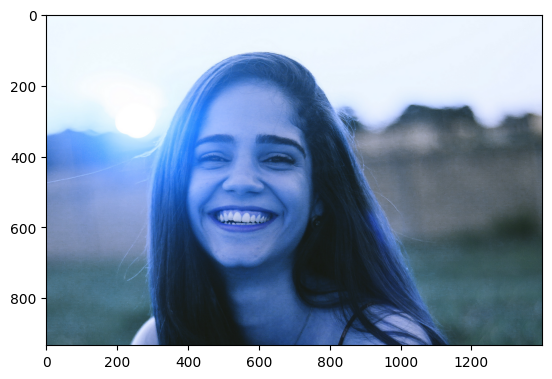

In [11]:
plt.imshow(img)

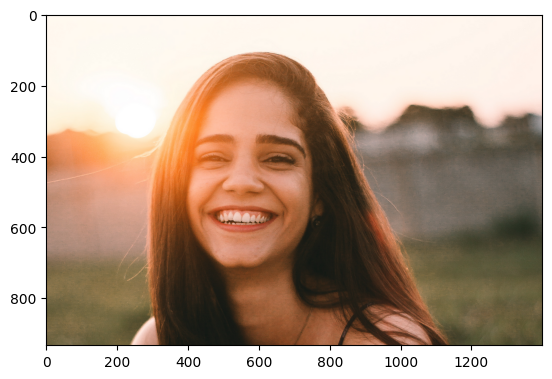

In [12]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [13]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print(f"Image not in ext list {image_path} {tip}")
                os.remove(image_path)
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            #os.remove(image_path)

### 1.3 Load Data

In [14]:
import numpy as np

In [15]:
data = tf.keras.utils.image_dataset_from_directory??

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    **kwargs,
)
Source:   
@keras_export(
    "keras.utils.image_dataset_from_directory",
    "keras.preprocessing.image_dataset_from_directory",
    v1=[],
)
def image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    **kwargs,
):
    """Generates a `tf.data.Dataset` from image files in a directory.

    If your directory structure is:



In [16]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 359 files belonging to 2 classes.


In [17]:
date_iterator = data.as_numpy_iterator()

2025-06-07 19:14:26.248154: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]
2025-06-07 19:14:26.250884: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]


In [18]:
batch = date_iterator.next()

2025-06-07 19:14:27.096682: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 59101500 exceeds 10% of free system memory.
2025-06-07 19:14:27.858405: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 66355200 exceeds 10% of free system memory.
2025-06-07 19:14:27.858405: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 66355200 exceeds 10% of free system memory.
2025-06-07 19:14:28.401322: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25440000 exceeds 10% of free system memory.
2025-06-07 19:14:28.401322: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25440000 exceeds 10% of free system memory.
2025-06-07 19:14:29.311487: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22608000 exceeds 10% of free system memory.
2025-06-07 19:14:29.499819: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 23887872 exceeds 10% of free system memory.
2025-06-07 19:14:29.311487:

In [19]:
batch

(array([[[[2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          ...,
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02]],
 
         [[2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          ...,
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02]],
 
         [[2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          [2.53000000e+02, 2.44000000e+02, 2.39000000e+02],
          ...,
          [2.53000000e+02, 2.44000000e+02, 2.3900

In [20]:
len(batch)

2

In [21]:
batch[0].shape

(32, 256, 256, 3)

Class 1 = Sad People
Class 0 = Happy People

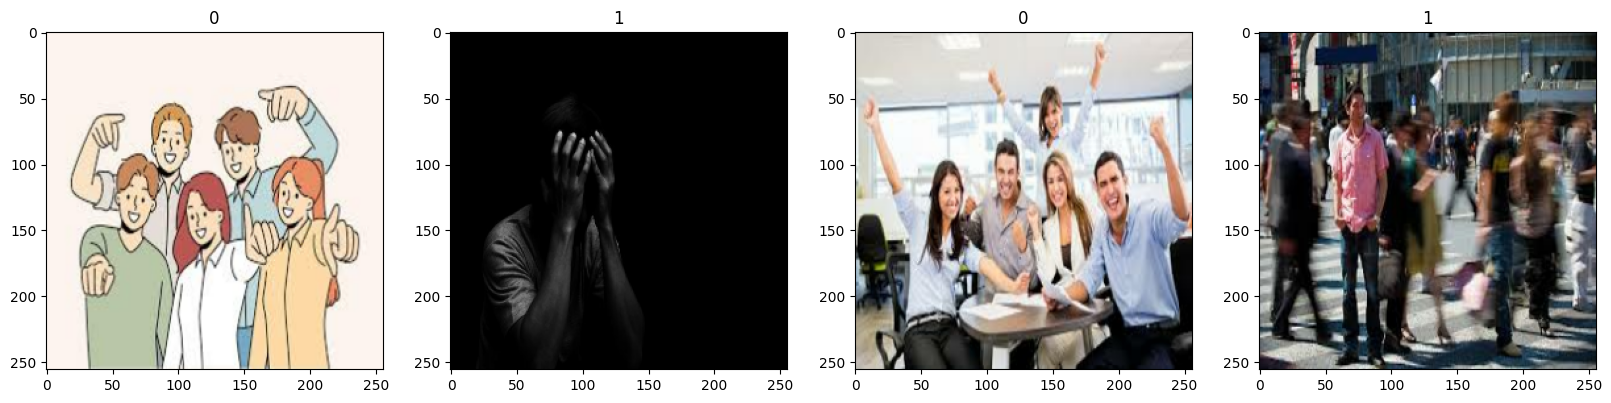

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

## 2. Preprocess Data

### 2.1 Scale Data

In [23]:
data = data.map(lambda x, y: (x / 255, y))

In [24]:
scale_iterator = data.as_numpy_iterator()

2025-06-07 19:14:35.000183: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]
2025-06-07 19:14:35.001148: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]


In [25]:
batch = scale_iterator.next()

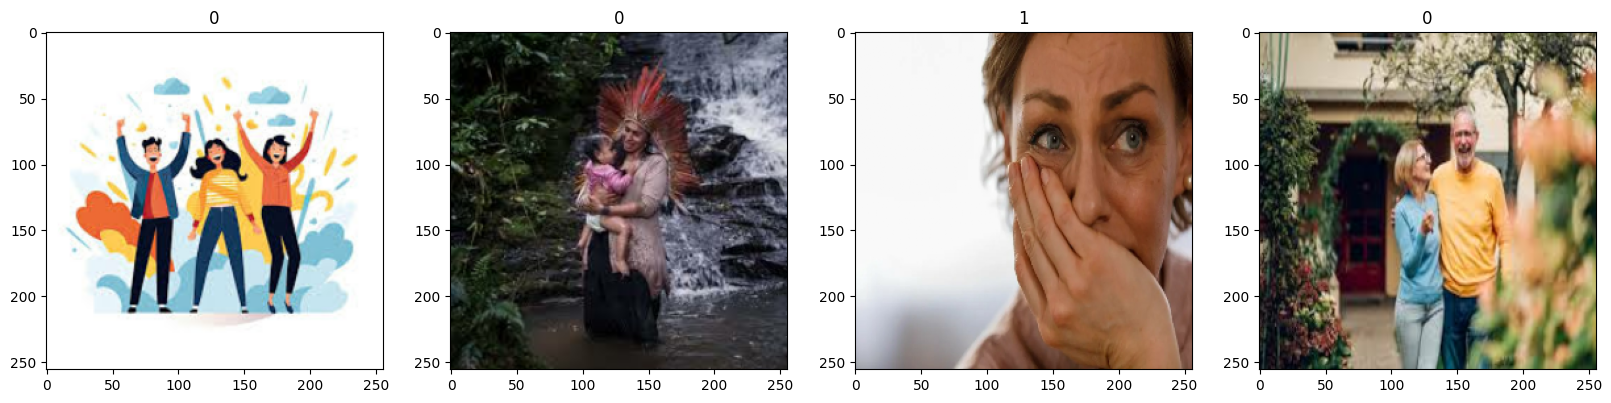

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

### 2.2 Split Data

In [27]:
len(data)

12

In [28]:
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)
test_size = len(data) - train_size - val_size

In [29]:
print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")

Train: 8, Val: 2, Test: 2


In [30]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [31]:
len(train), len(val), len(test)

(8, 2, 2)

## 3. Deep Model

### 3.1 Build Deep Learning Model

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [33]:
model = Sequential()

In [34]:
model.add(Conv2D(16, (3, 3), 1, activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3, 3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3, 3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [35]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 16)      448       
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 16)     0         
 )                                                               
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 16)     0         
 )                                                               
                                                                 
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      4

In [36]:
model.compile(optimizer='adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

### 3.2 Train

In [37]:
logdir = 'logs'

In [38]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [39]:
hist = model.fit(train, validation_data=val, epochs=20, callbacks=[tensorboard_callback])

Epoch 1/20


2025-06-07 19:14:49.723059: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]
2025-06-07 19:14:49.724050: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]


8/8 [==============================] - ETA: 0s - loss: 0.7667 - accuracy: 0.4844

2025-06-07 19:15:20.152780: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [359]
	 [[{{node Placeholder/_0}}]]
2025-06-07 19:15:20.153610: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]


8/8 [==============================] - 36s 3s/step - loss: 0.7667 - accuracy: 0.4844 - val_loss: 0.6066 - val_accuracy: 0.6250
Epoch 2/20
Epoch 2/20
8/8 [==============================] - 23s 3s/step - loss: 0.5861 - accuracy: 0.6484 - val_loss: 0.5719 - val_accuracy: 0.7344
Epoch 3/20
Epoch 3/20
8/8 [==============================] - 22s 2s/step - loss: 0.5625 - accuracy: 0.7578 - val_loss: 0.4350 - val_accuracy: 0.8438
Epoch 4/20
Epoch 4/20
8/8 [==============================] - 23s 3s/step - loss: 0.5407 - accuracy: 0.7891 - val_loss: 0.4806 - val_accuracy: 0.8281
Epoch 5/20
Epoch 5/20
8/8 [==============================] - 26s 2s/step - loss: 0.4123 - accuracy: 0.8516 - val_loss: 0.4152 - val_accuracy: 0.8125
Epoch 6/20
Epoch 6/20
8/8 [==============================] - 17s 2s/step - loss: 0.3835 - accuracy: 0.8359 - val_loss: 0.3115 - val_accuracy: 0.9062
Epoch 7/20
Epoch 7/20
8/8 [==============================] - 17s 2s/step - loss: 0.3362 - accuracy: 0.8672 - val_loss: 0.2574 - 

### 3.3 Plot Performance

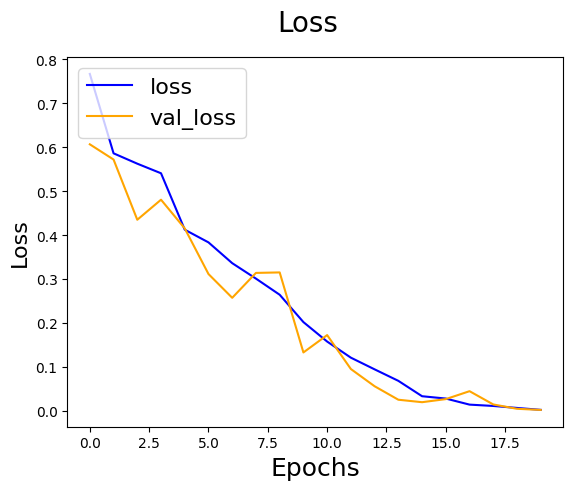

In [40]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='blue', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.xlabel('Epochs', fontsize=18)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc='upper left', fontsize=16)
plt.show()

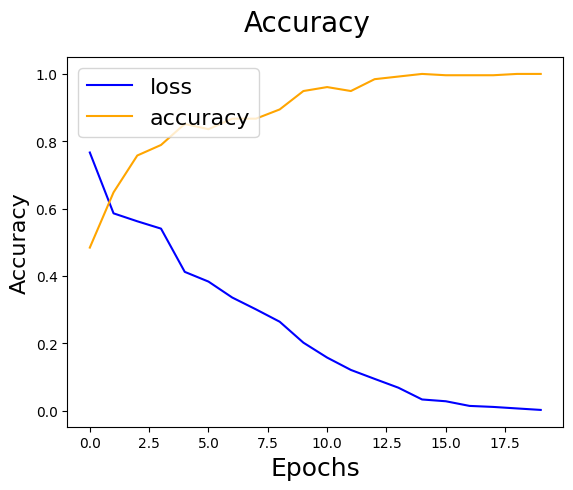

In [41]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='blue', label='loss')
plt.plot(hist.history['accuracy'], color='orange', label='accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.xlabel('Epochs', fontsize=18)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc='upper left', fontsize=16)
plt.show()

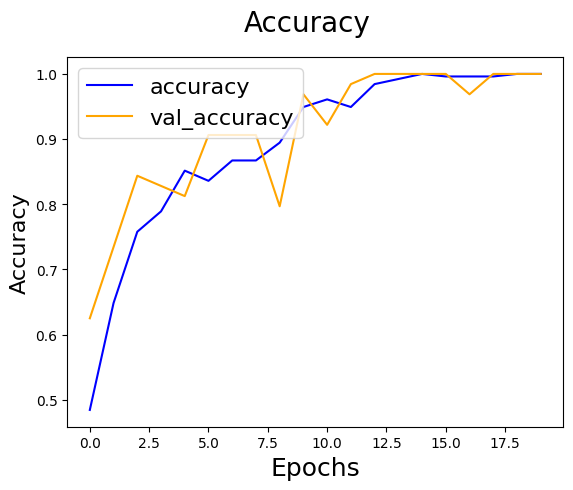

In [42]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='blue', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.xlabel('Epochs', fontsize=18)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc='upper left', fontsize=16)
plt.show()

## 4. Evaluate Performance

### 4.1 Evaluate

In [43]:
from tensorflow.keras.metrics import Accuracy, Precision, Recall, BinaryAccuracy

In [44]:
precision = Precision()
recall = Recall()
accuracy = BinaryAccuracy()

In [45]:
for batch in test.as_numpy_iterator():
    X, y = batch
    y_pred = model.predict(X)
    # y_pred = np.where(y_pred > 0.5, 1, 0)
    
    precision.update_state(y, y_pred)
    recall.update_state(y, y_pred)
    accuracy.update_state(y, y_pred)

2025-06-07 19:23:34.653930: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]
2025-06-07 19:23:34.655095: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [359]
	 [[{{node Placeholder/_4}}]]


1/1 [==============================] - 0s 317ms/step


In [46]:
print(f"Precision: {precision.result().numpy()}")
print(f"Recall: {recall.result().numpy()}")
print(f"Accuracy: {accuracy.result().numpy()}")

Precision: 1.0
Recall: 1.0
Accuracy: 1.0


### 4.2 Test

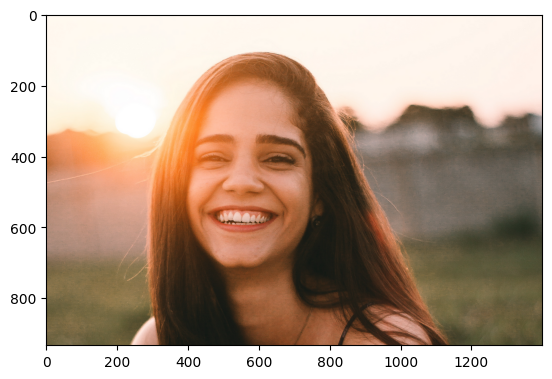

In [47]:
img = cv2.imread(os.path.join(data_dir, 'happy', '4-things-happy-people-dont-do-cover.png'))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

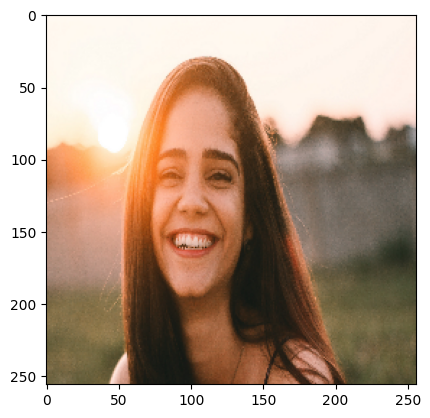

In [48]:
resize_img = cv2.resize(img, (256, 256))
plt.imshow(cv2.cvtColor(resize_img, cv2.COLOR_BGR2RGB))
plt.show()

In [49]:
y_pred = model.predict(np.expand_dims(resize_img / 255, axis=0))

1/1 [==============================] - 0s 142ms/step


In [50]:
y_pred

array([[0.9214829]], dtype=float32)

In [51]:
# For happy image test
if y_pred > 0.5:
    print("Sad")  # Class 1 = Sad
else:
    print("Happy")  # Class 0 = Happy

Sad


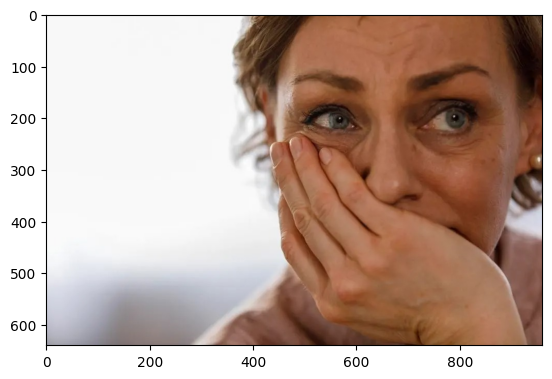

In [52]:
img = cv2.imread(os.path.join(data_dir, 'sad', '960x0.jpg'))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [53]:
resize_img1 = cv2.resize(img, (256, 256))
y_pred1 = model.predict(np.expand_dims(resize_img1 / 255, axis=0))

1/1 [==============================] - 0s 303ms/step


In [54]:
y_pred1

array([[0.97837985]], dtype=float32)

In [55]:
# For sad image test
if y_pred1 > 0.5:
    print("Sad")  # Class 1 = Sad
else:
    print("Happy")  # Class 0 = Happy

Sad


## 5. Save the Model

## 5.1 Save Model

In [56]:
from tensorflow.keras.models import load_model

In [57]:
model.save(os.path.join('models', 'happy_sad_model.h5'))

In [58]:
new_model = load_model(os.path.join('models', 'happy_sad_model.h5'))

In [59]:
y_pred_new = new_model.predict(np.expand_dims(resize_img / 255, axis=0))

1/1 [==============================] - 0s 311ms/step


In [60]:
# For test with new model
if y_pred_new > 0.5:
    print("Sad")  # Class 1 = Sad
else:
    print("Happy")  # Class 0 = Happy

Sad


# Model Class Encoding
Our model uses binary classification with the following encoding:
- Class 0 = Happy People (model output < 0.5)
- Class 1 = Sad People (model output >= 0.5)

This means:
- When model predicts > 0.5: Image is classified as "Sad"
- When model predicts < 0.5: Image is classified as "Happy"